## Target dari isi notebook ini:
- memperbaiki kualitas NLP pipeline
- meningkatkan performa model
- memperbaiki neutral class
- melakukan slang normalization
- melakukan model comparison
- melakukan hyperparameter tuning
- melakukan cross validation
- memilih final model production-ready

In [1]:
from tqdm import tqdm
import re
import string
import numpy as np
import pandas as pd
import seaborn as sns
import emoji
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)
from sklearn.feature_extraction.text import (
    TfidfVectorizer
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
import joblib

In [2]:
resources = [
    "punkt",
    "punkt_tab",
    "stopwords"
]

for resource in resources:
    nltk.download(resource)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Erland\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Erland\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Erland\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df = pd.read_csv(
    "../datasets/X_review_GP/processed/final_clean_dataset.csv"
)

display(df.head())
print(f"\nJumlah baris dan kolom: {df.shape}")

print("\nJumlah missing values")
print("=" * 30)
print(df.isnull().sum())

print("\nDistribusi label")
print("=" * 30)
print(df["label"].value_counts())

,text,rating,label,clean_text,text_length
0,"ya,bagus",4,positive,ya bagus,8
1,mohon bantuannya saya tidak bisa mengubah nama...,2,negative,mohon bantu ubah nama guna,26
2,tolong lah X (sebelumnya Twiter) akun saya tid...,3,neutral,tolong x twiter akun upload langgar tdk koment...,80
3,update selalu 🫰🏻,5,positive,update,6
4,"sangat menyebalkan, hampir setiap membuka apk ...",1,negative,sebal buka apk x pinta verifikasi email,39



Jumlah baris dan kolom: (64341, 5)

Jumlah missing values
text           0
rating         0
label          0
clean_text     0
text_length    0
dtype: int64

Distribusi label
label
negative    41994
positive    18544
neutral      3803
Name: count, dtype: int64


## 1. Slang Normalization

In [4]:
from collections import Counter

all_words = ' '.join(df['clean_text']).split()

word_freq = Counter(all_words)

word_freq.most_common(1500)

[('akun', 12137),
 ('aplikasi', 9431),
 ('twitter', 7982),
 ('ga', 7018),
 ('nya', 6997),
 ('gak', 6503),
 ('x', 5867),
 ('bagus', 5611),
 ('login', 5581),
 ('aja', 5565),
 ('apk', 4653),
 ('banget', 4122),
 ('yg', 4081),
 ('tolong', 3936),
 ('masuk', 3853),
 ('video', 3825),
 ('update', 3755),
 ('buka', 3679),
 ('tangguh', 3582),
 ('udah', 3315),
 ('baik', 3158),
 ('jelek', 3133),
 ('susah', 2955),
 ('daftar', 2936),
 ('gk', 2869),
 ('ya', 2709),
 ('suka', 2464),
 ('salah', 2462),
 ('gabisa', 2363),
 ('aneh', 2204),
 ('bikin', 2157),
 ('elon', 2148),
 ('sih', 2004),
 ('mulu', 1967),
 ('ganti', 1899),
 ('kali', 1812),
 ('nomor', 1805),
 ('pas', 1796),
 ('bug', 1795),
 ('i', 1684),
 ('gw', 1647),
 ('bgt', 1629),
 ('the', 1591),
 ('pake', 1524),
 ('lot', 1523),
 ('bintang', 1487),
 ('jaring', 1431),
 ('orang', 1412),
 ('coba', 1407),
 ('nama', 1404),
 ('verifikasi', 1395),
 ('no', 1379),
 ('ribet', 1354),
 ('kalo', 1339),
 ('udh', 1322),
 ('download', 1282),
 ('guna', 1265),
 ('kasih', 1

In [5]:
slang_dict = {
    # NEGATION
    "g": "tidak",
    "ga": "tidak",
    "gak": "tidak",
    "gk": "tidak",
    "ngga": "tidak",
    "nga": "tidak",
    "nggak": "tidak",
    "enggak": "tidak",
    "ngak": "tidak",
    "ngk": "tidak",
    "tdk": "tidak",
    "kaga": "tidak",
    "kagak": "tidak",
    "tidaak": "tidak",
    "tidka": "tidak",

    # NEGATIVE EXPRESSIONS
    "gabisa": "tidak bisa",
    "gbisa": "tidak bisa",
    "gbs": "tidak bisa",
    "gaje": "tidak jelas",
    "gjls": "tidak jelas",
    "gj": "tidak jelas",
    "gjelas": "tidak jelas",
    "gajelas": "tidak jelas",
    "gada": "tidak ada",
    "gaada": "tidak ada",
    "gtw": "tidak tau",
    "habisa": "tidak bisa",
    "gatau": "tidak tau",

    # APPLICATION / TECH
    "apk": "aplikasi",
    "apl": "aplikasi",
    "apps": "aplikasi",
    "app": "aplikasi",
    "apknya": "aplikasinya",
    "eror": "error",
    "ban": "suspend",
    "suspend": "ditangguhkan",
    "pfp": "foto profil",
    "dm": "direct message",

    # PRONOUN
    "ak": "aku",
    "sy": "aku",
    "sya": "aku",
    "gw": "aku",
    "gua": "aku",
    "gue": "aku",
    "lu": "kamu",
    "lo": "kamu",

    # EMPHASIS
    "bgt": "banget",
    "bgtt": "banget",
    "bngt": "banget",
    "bnget": "banget",
    "bbget": "banget",
    "bngtt": "banget",

    # COMMON WORDS
    "yg": "yang",
    "pake": "pakai",
    "make": "pakai",
    "kalo": "kalau",
    "klo": "kalau",
    "tp": "tapi",
    "tpi": "tapi",
    "ttp": "tetapi",
    "udh": "sudah",
    "udah": "sudah",
    "uda": "sudah",
    "sdh": "sudah",
    "sdah": "sudah",
    "blm": "belum",
    "skrg": "sekarang",
    "skrng": "sekarang",
    "lg": "lagi",
    "lgi": "lagi",
    "dlu": "dulu",
    "bener": "benar",
    "karna": "karena",
    "krna": "karena",
    "ilang": "hilang",
    "jls": "jelas",
    "knp": "kenapa",
    "knpa": "kenapa",
    "ngapa": "kenapa",
    "napa": "kenapa",
    "pdhl": "padahal",
    "trus": "terus",
    "trs": "terus",
    "moga": "semoga",
    "jd": "jadi",
    "jdi": "jadi",
    "jg": "juga",
    "bs": "bisa",
    "bsa": "bisa",
    "org": "orang",
    "kasi": "kasih",
    "bgus": "bagus",
    "jgn": "jangan",
    "nyari": "mencari",
    "nyoba": "mencoba",
    "bnyk": "banyak",
    "bnyak": "banyak",
    "burem": "buram",
    "ad": "ada",
    "dr": "dari",
    "dri": "dari",
    "dgn": "dengan",
    "ny": "nya",
    "aj": "saja",
    "aje": "saja",
    "gmn": "bagaimana",
    "gmna": "bagaimana",
    "kluar": "keluar",
    "slalu": "selalu",
    "mkin": "makin",
    "jlek": "jelek",
    "mmuaskan": "memuaskan",
    "mantip": "mantap",
    "mantapu": "mantap",
    "skli": "sekali",
    "kluar²": "keluar keluar",
    "posotif": "positif",
    "hbis": "habis",
    "kebnyakan": "kebanyakan",
    "krn": "karena",
    "apklsi": "aplikasi",
    "dngn": "dengan",
    "hbis": "habis",
    "pdahal": "padahal",
    "kebnyakan": "kebanyakan",
    "dr": "dari",
    "maasnnttap": "mantap",
    "mantab": "mantap",
    "jls": "jelas",
    "turup": "tutup",
    "tmbh": "tambah",
    "bgs": "bagus",
    "amantap": "mantap",
    "ntap": "mantap",
    "gaasik": "tidak asik",
    "jellek": "jelek",
    "jeleek": "jelek",

    # SOCIAL MEDIA TERMS
    "twiter": "twitter",
    "twit": "tweet",
    "twitt": "tweet",
    "twt": "tweet",
    "twet": "tweet",

    # TOXIC WORDS
    "ajg": "anjing",
    "anj": "anjing",
    "anjeng": "anjing"
}

In [6]:
# Custom Stopword Indonesia
factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()
important_words = [
    # NEGATION
    "tidak",
    "tak",
    "bukan",
    "belum",
    "jangan",

    # EMPHASIS
    "banget",
    "sangat",
    "sekali",
    "terlalu",
    "lebih",
    "kurang",
    "parah",

    # SYSTEM / FUNCTIONAL
    "bisa",
    "tidak bisa",
    "gagal",
    "error",
    "loading",
    "login",
    "refresh",

    # EMOTION
    "suka",
    "senang",
    "kecewa",
    "kesal",
    "emosi",
    "marah",
    "sedih",

    # SENTIMENT WORDS
    "bagus",
    "jelek",
    "buruk",
    "keren",
    "mantap",
    "lambat",
    "cepat",

    # TIME / COMPARISON
    "sekarang",
    "dulu",
    "lagi",

    # PLATFORM TERMS
    "twitter",
    "tweet",
    "akun",
    "suspend",
    "ditangguhkan",
]
stopwords = set(stopwords)
for word in important_words:
    stopwords.discard(word)

In [7]:
def remove_stopwords(tokens):
    filtered_tokens = []
    for token in tokens:
        if token not in stopwords:
            filtered_tokens.append(token)
    return filtered_tokens

def normalize_slang(tokens):
    normalized = []
    for word in tokens:
        normalized.append(
            slang_dict.get(word, word)
        )
    return normalized

def case_folding(text):
    text = text.lower()
    return text

def normalize_repeated_characters(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

def remove_url(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', text)

def remove_mention_hashtag(text):
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    return text

def remove_emoji(text):
    return emoji.replace_emoji(text, replace='')

def remove_numbers(text):
    return re.sub(r'\d+', '', text)

def remove_punctuation(text):
    return re.sub(
        f"[{re.escape(string.punctuation)}]",
        " ",
        text
    )

def remove_whitespace(text):
    return text.strip()

def remove_multiple_spaces(text):
    return re.sub(r'\s+', ' ', text)

def tokenize(text):
    return word_tokenize(text)

In [8]:
def preprocess_text(text):
    text = case_folding(text)
    text = normalize_repeated_characters(text)
    text = remove_url(text)
    text = remove_mention_hashtag(text)
    text = remove_emoji(text)
    text = remove_numbers(text)
    text = remove_punctuation(text)
    text = remove_whitespace(text)
    text = remove_multiple_spaces(text)
    tokens = tokenize(text)
    tokens = normalize_slang(tokens)
    tokens = remove_stopwords(tokens)
    tokens = [
        token
        for token in tokens
        if token.strip()
    ]
    text = ' '.join(tokens)
    
    return text

### Test

In [9]:
sample = "apk gk bisa login banget skrng"

print(preprocess_text(sample))

aplikasi tidak bisa login banget sekarang


## 2. Reprocess Dataset

In [10]:
tqdm.pandas()

df["clean_text"] = df["text"].progress_apply(
    preprocess_text
)

100%|███████████████████████████████████████████████████████████████| 64341/64341 [00:19<00:00, 3295.30it/s]


In [11]:
# Cek clean_text
df[['text', 'clean_text', 'label']].sample(30)

,text,clean_text,label
13716,Bad very very bed semejak dialihkan kepemilika...,bad very very bed semejak dialihkan kepemilika...,negative
50122,Bisa gak sih lu gausah ngasih pembatasan jumla...,bisa tidak sih kamu gausah ngasih pembatasan j...,neutral
60309,Bantu saya menang big win di twitter ya,bantu menang big win twitter,positive
4624,ga ada ngapa²in tiba² akun langsung ditangguhk...,tidak ngapa²in tiba² akun langsung ditangguhka...,negative
55767,"V "". X?""2!!✓.""VC *d d "" x:* .XX .,vc. "";X.u b ...",v x ✓ vc d d x xx vc x u b vcavn z v z x zbbz ...,neutral
21408,"X is a bad app, not a good recommendation to d...",x is a bad aplikasi not a good recommendation ...,negative
8958,Diupdate malah ngblank..ga bisa dibuka,diupdate malah ngblank tidak bisa dibuka,negative
63482,"bagus kok apk nya, tpi ngga tau beberapa hari ...",bagus kok aplikasi nya tidak tau beberapa hari...,positive
33773,Very cool,very cool,positive
32129,Kenapa trending-nya sering gak valid. Lokasi g...,trending nya sering tidak valid lokasi tidak s...,negative


## 3. Validasi Dataset

In [12]:
# Missing values & Empty Text
print("Missing Values")
print("=" * 30)
print(df.isnull().sum())
print(f"\nEmpty text pada kolom 'clean_text': {(df['clean_text'].str.strip() == '').sum()}")

Missing Values
text           0
rating         0
label          0
clean_text     0
text_length    0
dtype: int64

Empty text pada kolom 'clean_text': 14


In [13]:
# Empty text nya
df[df['clean_text'].str.strip() == ''][['text', 'clean_text']].head(20)

,text,clean_text
40,ok,
2787,ok ok Ok,
14434,Ok ok 👍👍👍👍,
22570,Udah,
24678,oh,
29455,Knpa,
31948,Ok Ya,
32609,Anu,
32652,Udh,
37367,Dr Ya,


In [14]:
# Hapus empty text
df = df[df["clean_text"].str.strip() != ""]
df = df.reset_index(drop=True)

In [15]:
# Validasi empty text setelah dihapus
print(f"Jumlah empty text setelah dihapus: {(df['clean_text'].str.strip() == '').sum()}")

Jumlah empty text setelah dihapus: 0


## 4. Train-Test Split

In [16]:
X = df['clean_text']
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 5. TF-IDF Optimization

In [17]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## 6. Model Training

## Logistic Regression

In [18]:
lr_model = LogisticRegression(
    C=0.5,
    max_iter=2000,
    class_weight='balanced'
)

lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

In [19]:
# Classification Report
print(classification_report(y_test, lr_pred))

# Accuracy Score
print(accuracy_score(y_test, lr_pred))

              precision    recall  f1-score   support

    negative       0.90      0.75      0.82      8399
     neutral       0.14      0.36      0.20       761
    positive       0.75      0.79      0.77      3706

    accuracy                           0.74     12866
   macro avg       0.60      0.63      0.60     12866
weighted avg       0.81      0.74      0.77     12866

0.7373698119073527


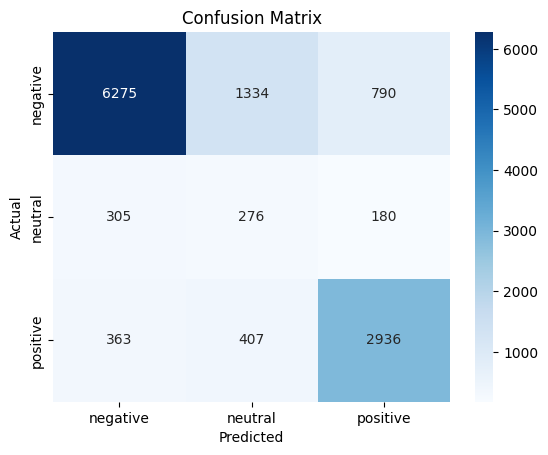

In [20]:
# Confussion Matrix
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 7. Model Comparison

### 7.1. Naive Bayes

In [21]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

In [22]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

    negative       0.80      0.96      0.87      8399
     neutral       0.50      0.00      0.00       761
    positive       0.83      0.63      0.72      3706

    accuracy                           0.81     12866
   macro avg       0.71      0.53      0.53     12866
weighted avg       0.79      0.81      0.78     12866



### 7.2. Linear SVM

In [23]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

In [24]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

    negative       0.85      0.92      0.88      8399
     neutral       0.24      0.03      0.06       761
    positive       0.78      0.77      0.77      3706

    accuracy                           0.82     12866
   macro avg       0.62      0.57      0.57     12866
weighted avg       0.79      0.82      0.80     12866



## 8. Error Analysis

In [25]:
evaluation_df = pd.DataFrame({
    "clean_text": X_test,
    "actual": y_test,
    "predicted": lr_pred
})

wrong_predictions = evaluation_df[evaluation_df["actual"] != evaluation_df["predicted"]]
wrong_predictions.sample(30)

,clean_text,actual,predicted
22688,apa yak salah,negative,neutral
30221,please update twitter or x designed for tablet...,negative,positive
12924,login eh malah akun ku terkunci aduhh bagaiman...,positive,negative
32191,kurang suka ama logonya anjay,negative,neutral
16628,akun tangguhkan padahal tidak pernah melanggar...,positive,negative
4001,apa nih tidak bisa upload update stts kocak iz...,neutral,negative
40634,gote,negative,positive
12154,tadinya pakai x lumayan enak meskipun sering b...,negative,neutral
15624,byk bug nya ngend,negative,neutral
7317,samsung a tidak bisa tampilkan konten dilarang...,negative,neutral


## 9. Cross Validation

In [26]:
scores = cross_val_score(
    lr_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='f1_weighted'
)

print(scores)

print(scores.mean())

[0.75375071 0.7589345  0.76032318 0.75444717 0.75574324]
0.7566397603212129


## 10. Simpan Model

In [27]:
joblib.dump(lr_model, "../models/logistic_regression_model_v1.pkl")

['../models/logistic_regression_model_v1.pkl']

In [28]:
joblib.dump(tfidf, "../models/tfidf.pkl")

['../models/tfidf.pkl']

In [30]:
import sys
sys.path.append("..")
from src.preprocessing import preprocess_text

print(pre.preprocess_text("APK gk bisa login banget 😭"))

aplikasi tidak bisa login banget
